<a href="https://colab.research.google.com/github/SoniaElizabeth/ICT_DSA_2026/blob/main/Deep_learning_Casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.datasets import cifar100

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, Flatten, Dropout,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator




import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Load dataset

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print(x_train.shape)
print(x_test.shape)

## Normalizing

In [ ]:
## Normalize pixel value

x_train = x_train / 255.0
x_test = x_test / 255.0

## One-hot encode

In [ ]:
# One-hot encoding

y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

## Custom CNN

In [ ]:
model_cnn = models.Sequential()

# First Convolution Block
model_cnn.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    kernel_initializer='he_normal',
    input_shape=(32,32,3)
))

model_cnn.add(layers.BatchNormalization())

model_cnn.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
))

model_cnn.add(layers.MaxPooling2D((2,2)))
model_cnn.add(layers.Dropout(0.25))

# Second Convolution Block
model_cnn.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model_cnn.add(layers.BatchNormalization())

model_cnn.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
))

model_cnn.add(layers.MaxPooling2D((2,2)))
model_cnn.add(layers.Dropout(0.25))

# Third Convolution Block
model_cnn.add(layers.Conv2D(
    128,
    (3,3),
    activation='relu',
    padding='same'
))

model_cnn.add(layers.BatchNormalization())

model_cnn.add(layers.MaxPooling2D((2,2)))
model_cnn.add(layers.Dropout(0.3))

# Flatten Layer
model_cnn.add(layers.Flatten())

# Fully Connected Layer
model_cnn.add(layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.001)
))

model_cnn.add(layers.Dropout(0.5))

# Output Layer
model_cnn.add(layers.Dense(100, activation='softmax'))

## Compile the model

In [ ]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Model summary

In [ ]:
model_cnn.summary()

## Callbacks

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.keras',

    save_best_only=True
)


## Train the model

In [ ]:
history = model_cnn.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

## Model evaluation

In [ ]:
cnn_loss, cnn_acc = model_cnn.evaluate(x_test, y_test)

print("Test Accuracy:", cnn_acc)

## plotting

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# Load VGG16 base model

## Load dataset

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()


## Resize image

In [ ]:
x_train = tf.image.resize(x_train, (64, 64))
x_test = tf.image.resize(x_test, (64, 64))


## Adding VGG16 preprocessing

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

x_train = preprocess_input(x_train)
x_test = preprocess_input(x_test)

## One-hot enoding

In [ ]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)


## Data argumentation

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)


## Load pretrained VGG16

In [ ]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)

## FREEZE EARLY LAYERS


In [ ]:
for layer in base_model.layers[:-2]:
    layer.trainable = False

for layer in base_model.layers[-2:]:
    layer.trainable = True


## BUILD MODEL


In [ ]:
model = Sequential()

model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu',kernel_regularizer=l2(0.001)))
model.add(Dropout(0.6))
model.add(Dense(100, activation='softmax'))

## Compile Model

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## MOdel summary

In [ ]:
model.summary()

## Callbacks

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_vgg16_model.keras',
    save_best_only=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

## Train model

In [ ]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=16),
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, checkpoint, lr_reduce]
)

Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 100s 30ms/step - accuracy: 0.1091 - loss: 4.7949 - val_accuracy: 0.3277 - val_loss: 3.2404 - learning_rate: 1.0000e-04
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.2787 - loss: 3.3601 - val_accuracy: 0.4509 - val_loss: 2.4037 - learning_rate: 1.0000e-04
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 90s 29ms/step - accuracy: 0.3697 - loss: 2.7416 - val_accuracy: 0.5075 - val_loss: 2.0524 - learning_rate: 1.0000e-04
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 28ms/step - accuracy: 0.4267 - loss: 2.3873 - val_accuracy: 0.5274 - val_loss: 1.8975 - learning_rate: 1.0000e-04
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.4726 - loss: 2.1671 - val_accuracy: 0.5524 - val_loss: 1.7848 - learning_rate: 1.0000e-04
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 89s 29ms/step - accuracy: 0.5035 - loss: 2.0148 - val_accuracy: 0.5646 - val_loss: 1.7137 - learning_rate: 1.0000e-04
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━

## Evaluate Model


In [ ]:
vgg_loss, vgg_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", vgg_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6320 - loss: 1.5391
Test Accuracy: 0.6320000290870667


## Accuracy Graph

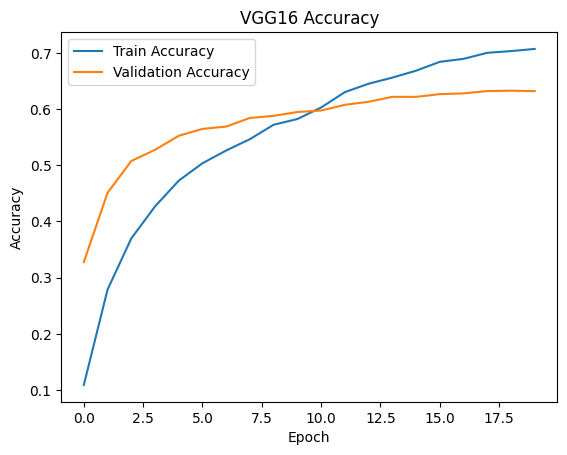

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 Accuracy')

plt.legend()
plt.show()


## Loss Graph

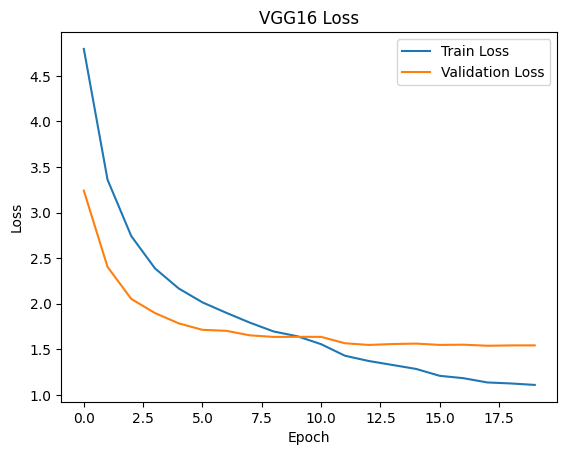

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 Loss')

plt.legend()
plt.show()

## Comparison bwtween CNN and VGG16

In [ ]:
import pandas as pd

df_compare = pd.DataFrame({
    "Model": ["Custom CNN", "VGG16"],
    "Test Accuracy": [f"{cnn_acc*100:.2f}%", f"{vgg_acc*100:.2f}%"]
})

df_compare

,Model,Test Accuracy
0,Custom CNN,52.48%
1,VGG16,63.20%
